10


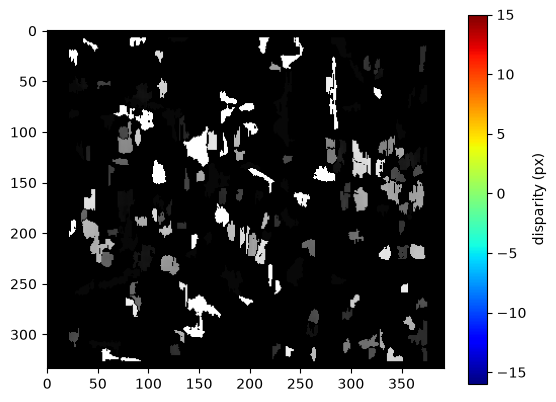

In [48]:
import numpy as np 
import cv2 as cv 

from matplotlib import pyplot as plt 
imgL = cv.imread('/Users/manankapoor/Developer/SEM5/Image-Processing /CV-Lab/assets/stereo/robot_left.png',cv.IMREAD_GRAYSCALE);
imgR = cv.imread('/Users/manankapoor/Developer/SEM5/Image-Processing /CV-Lab/assets/stereo/robot_right.png',cv.IMREAD_GRAYSCALE);


stereo = cv.StereoBM.create(numDisparities=32, blockSize=15)
stereo.setMinDisparity(-16)       # the key change
stereo.setUniquenessRatio(5)      # default is 15
stereo.setSpeckleWindowSize(50)   # optional: removes small isolated blobs
stereo.setSpeckleRange(2)


texture_threshold = cv.StereoBM.getTextureThreshold(stereo);
print(texture_threshold)
disparity = stereo.compute(imgL,imgR)
disp = disparity.astype(np.float32) / 16
disp = np.ma.masked_less(disp, stereo.getMinDisparity())   # hide invalid pixels
plt.imshow(disp, cmap="jet"); plt.colorbar(label="disparity (px)")

plt.imshow(disparity,'gray')
plt.show()

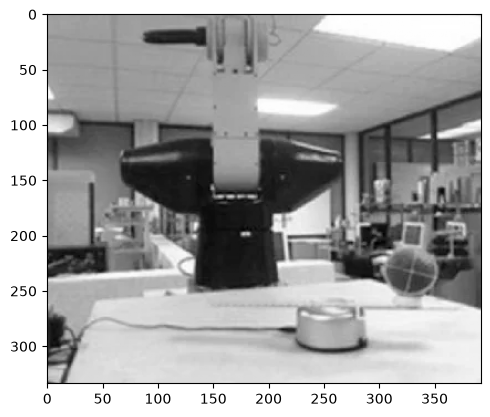

In [46]:
plt.imshow(imgL,'gray')